In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


# Load and prepare data
df = pd.read_csv('Spotify_Youtube.csv')
song_cnt = pd.DataFrame({"Songs":[df["Uri"].nunique()], "Artists":[df["Url_spotify"].nunique()]})
song_cnt

,Songs,Artists
0,18862,2079


In [5]:
## Top 10 most Streamed song
df.groupby(by = ["Track"], as_index = False)["Stream"].max().sort_values(by = ["Stream"], ascending=False).head(10)

,Track,Stream
1986,Blinding Lights,3.386520e+09
13160,Shape of You,3.362005e+09
13667,Someone You Loved,2.634013e+09
17589,rockstar (feat. 21 Savage),2.594927e+09
14107,Sunflower - Spider-Man: Into the Spider-Verse,2.538330e+09
10943,One Dance,2.522432e+09
2908,Closer,2.456205e+09
1774,Believer,2.369272e+09
12709,STAY (with Justin Bieber),2.365778e+09
13132,Señorita,2.336220e+09


In [6]:
## Top 10 most viewed youtube video
Channel_wise_views = df.groupby(by = ["Track","Channel"], as_index=False)["Views"].max()
Track_Wise_views = df.groupby(by = ["Track"], as_index=False)["Views"].sum()
Track_Wise_views.groupby(by = ["Track"], as_index = False)["Views"].max().sort_values(by = ["Views"], ascending=False).head(10)

,Track,Views
3713,Despacito,1.615930e+10
12997,See You Again (feat. Charlie Puth),1.154760e+10
8332,Lean On,9.974505e+09
13160,Shape of You,5.908398e+09
2489,Calma - Remix,5.322011e+09
15249,This Is What You Came For,5.252060e+09
14190,Swalla (feat. Nicki Minaj & Ty Dolla $ign),5.162404e+09
16666,Wheels on the Bus,4.898831e+09
14413,"Taki Taki (with Selena Gomez, Ozuna & Cardi B)",4.828403e+09
16004,Uptown Funk (feat. Bruno Mars),4.821016e+09


In [7]:
# data cleaning

url_cols = ['Unnamed: 0', 'Url_spotify', 'Uri', 'Url_youtube', 'Title', 'Description']
df.drop(url_cols, axis=1, inplace=True)
df.dropna(inplace=True)
df.isna().sum()

Artist              0
Track               0
Album               0
Album_type          0
Danceability        0
Energy              0
Key                 0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Duration_ms         0
Channel             0
Views               0
Likes               0
Comments            0
Licensed            0
official_video      0
Stream              0
dtype: int64

In [8]:
df.columns

Index(['Artist', 'Track', 'Album', 'Album_type', 'Danceability', 'Energy',
       'Key', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Duration_ms', 'Channel', 'Views',
       'Likes', 'Comments', 'Licensed', 'official_video', 'Stream'],
      dtype='object')

In [9]:
df.shape

(19549, 22)

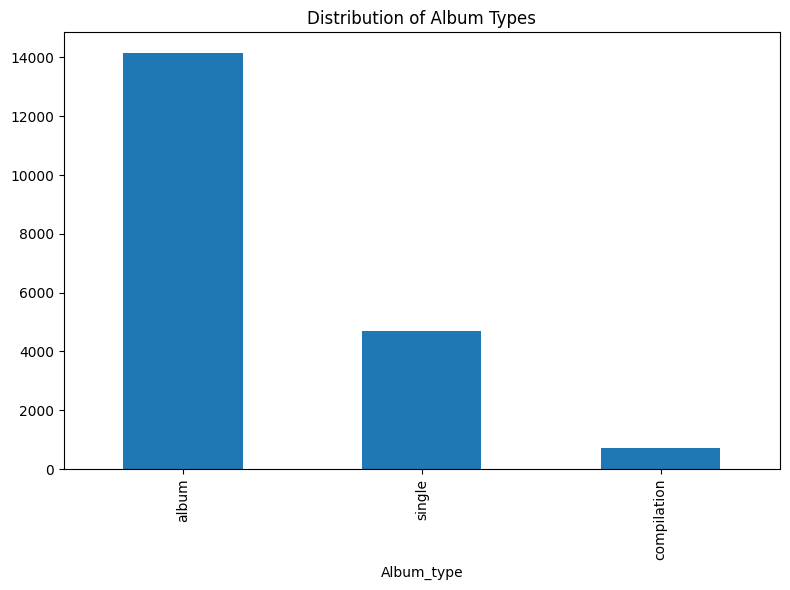


Top 10 Most Frequent Artist:
Artist
Gorillaz         10
Sam Smith        10
G-Eazy           10
Bomba Estéreo    10
Bonez MC         10
Skrillex         10
Demi Lovato      10
Avicii           10
Tame Impala      10
Ariana Grande    10
Name: count, dtype: int64

Top 10 Most Frequent Track:
Track
El Ultimo Adiós - Varios Artistas Version                     23
Color Esperanza 2020                                          19
Resistiré                                                     14
52 Non Stop Dilbar Dilbar Remix(Remix By Kedrock,Sd Style)     9
Valentine's Mashup 2019                                        9
Roll Me Up and Smoke Me When I Die - Live                      9
Heaven                                                         9
Poesia Acústica 13                                             7
Y, ¿Si Fuera Ella? - + Es +                                    7
Home                                                           7
Name: count, dtype: int64

Top 10 Most Frequent Albu

In [10]:
import matplotlib.pyplot as plt

# For Album_type (since it should have fewer categories)
plt.figure(figsize=(8, 6))
df['Album_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Album Types')
plt.tight_layout()
plt.show()

# For others, show value counts
for col in ['Artist', 'Track', 'Album']:
    print(f"\nTop 10 Most Frequent {col}:")
    print(df[col].value_counts().head(10))

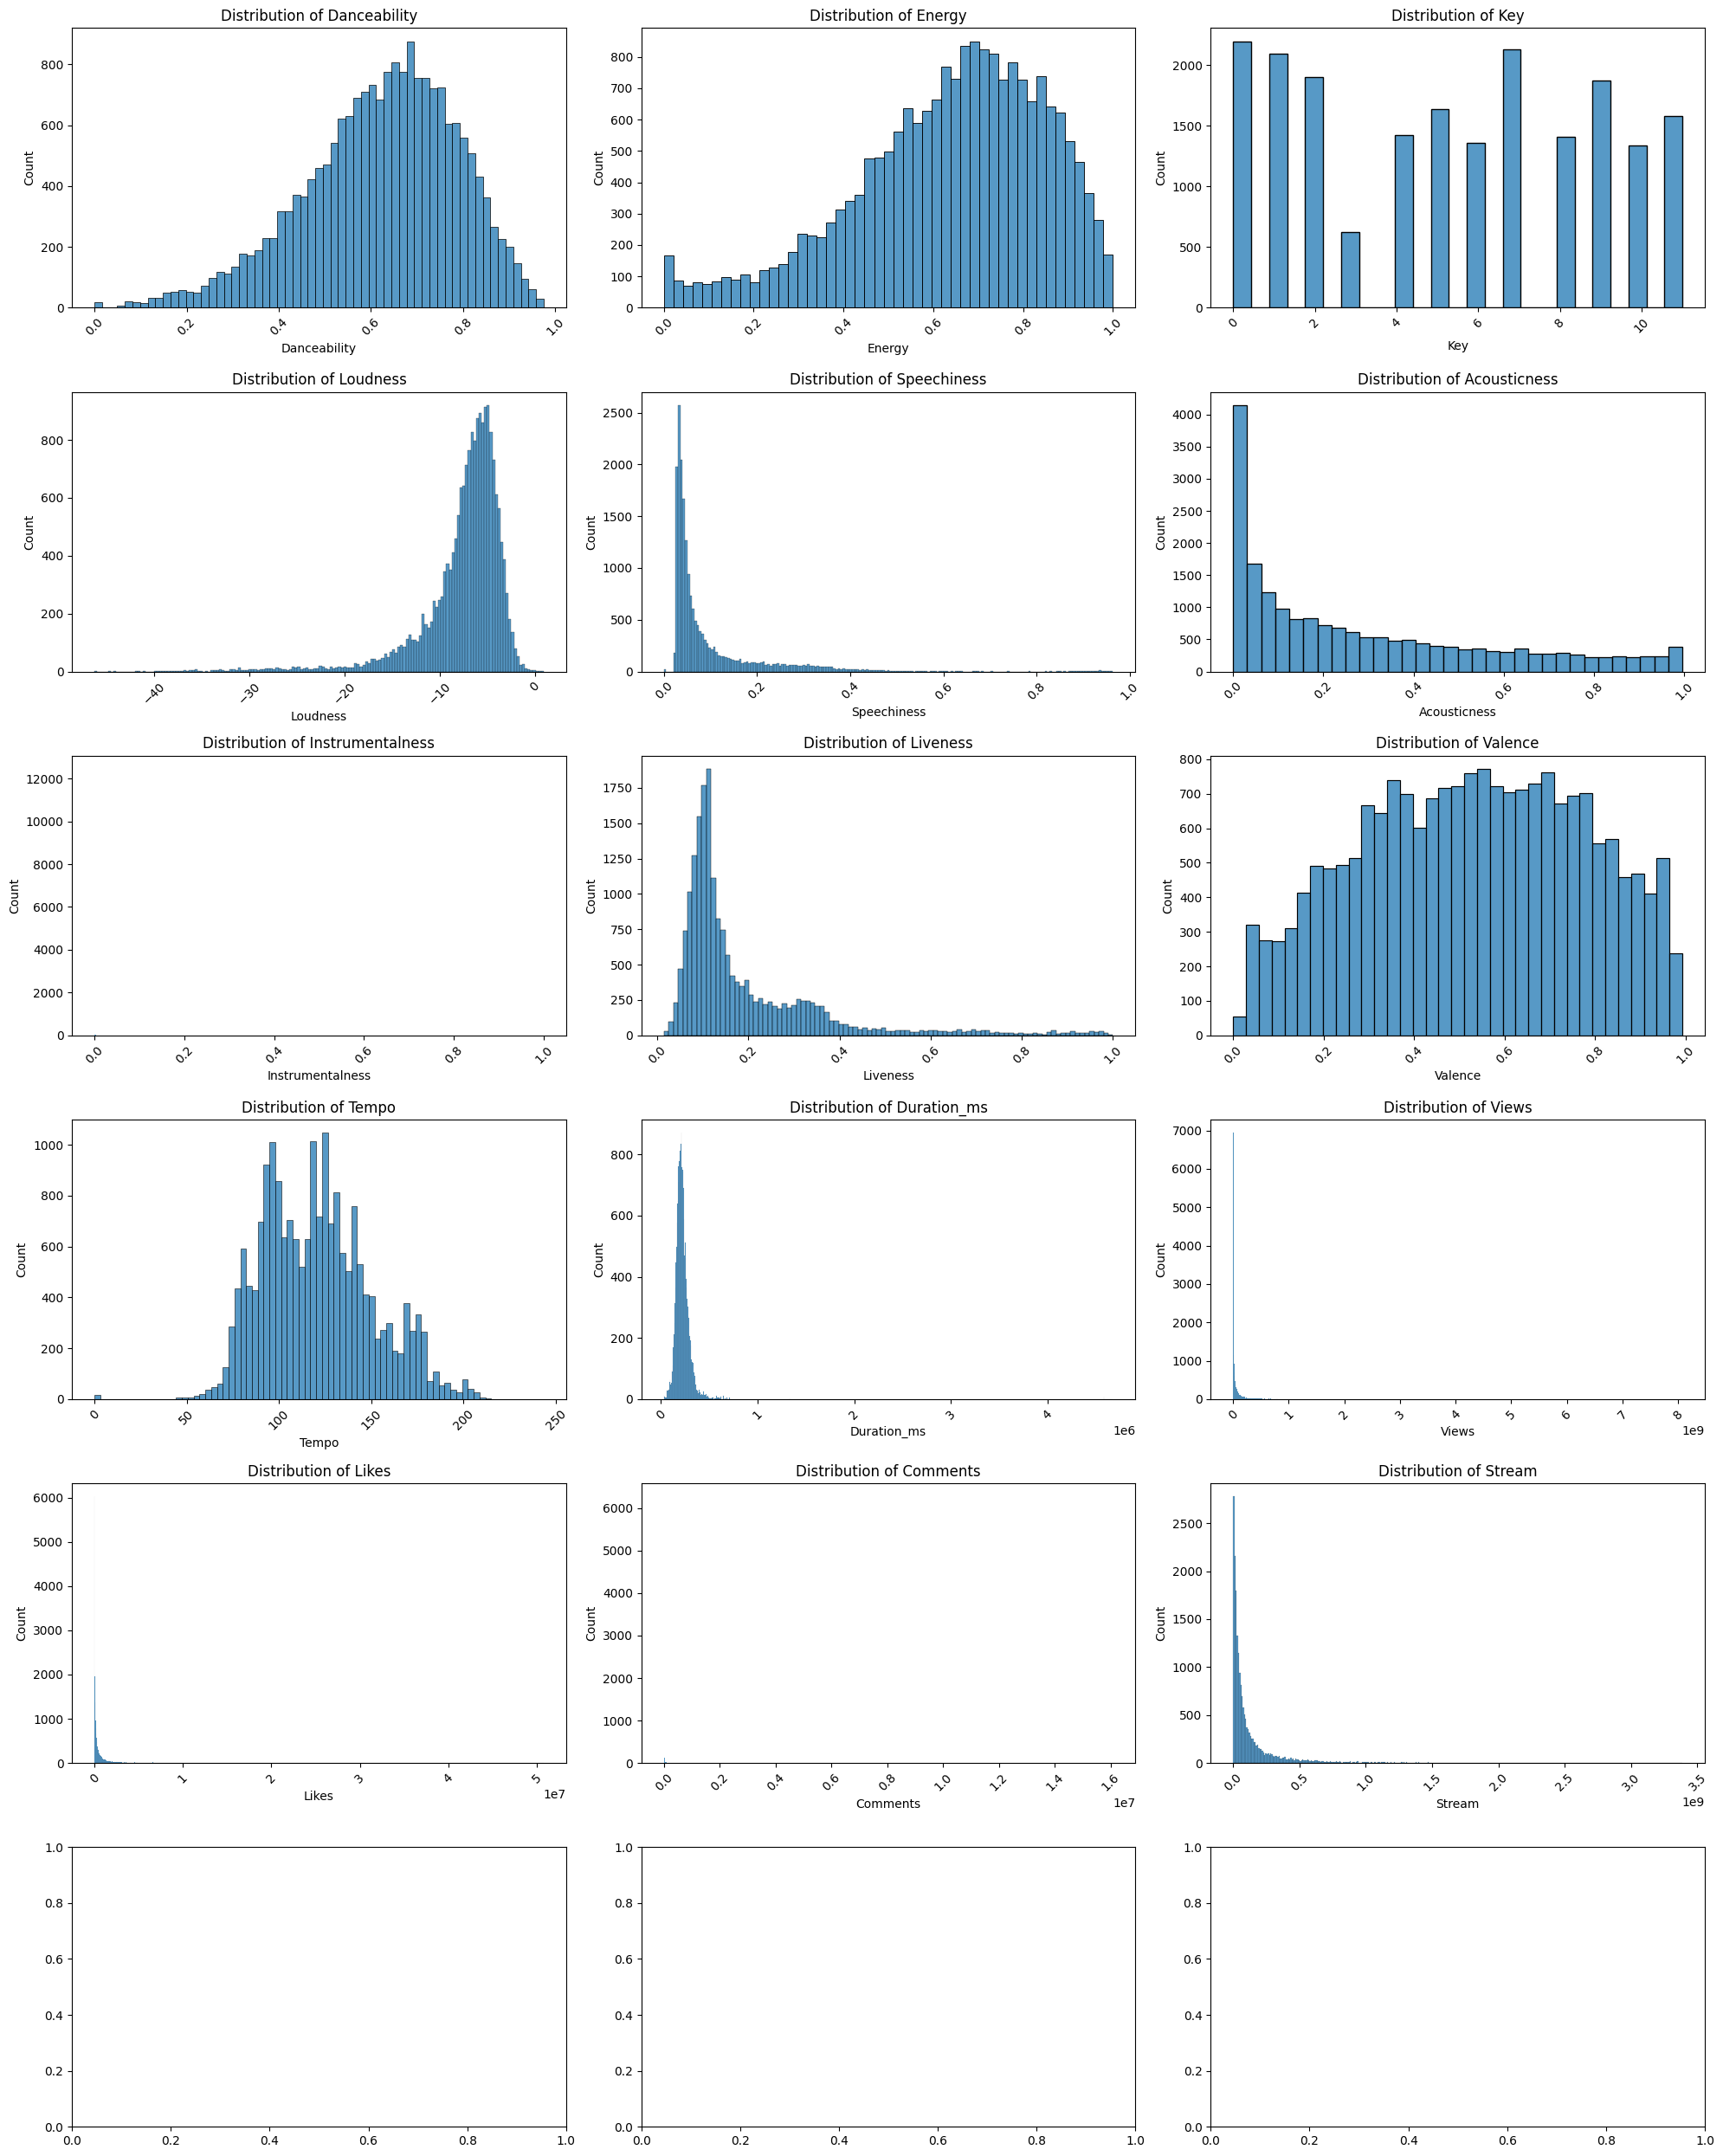

                    count          mean           std           min  \
Danceability      19549.0  6.210593e-01  1.654887e-01      0.000000   
Energy            19549.0  6.351700e-01  2.135545e-01      0.000020   
Key               19549.0  5.294337e+00  3.579338e+00      0.000000   
Loudness          19549.0 -7.633179e+00  4.618839e+00    -46.251000   
Speechiness       19549.0  9.539219e-02  1.062433e-01      0.000000   
Acousticness      19549.0  2.891060e-01  2.859085e-01      0.000001   
Instrumentalness  19549.0  5.529223e-02  1.925189e-01      0.000000   
Liveness          19549.0  1.912265e-01  1.651971e-01      0.014500   
Valence           19549.0  5.289503e-01  2.452280e-01      0.000000   
Tempo             19549.0  1.206057e+02  2.961934e+01      0.000000   
Duration_ms       19549.0  2.246281e+05  1.269126e+05  30985.000000   
Views             19549.0  9.545626e+07  2.775744e+08     26.000000   
Likes             19549.0  6.700487e+05  1.805054e+06      0.000000   
Commen

In [11]:
import seaborn as sns

# Create subplots for numerical columns
numerical_cols = ['Danceability', 'Energy',
       'Key', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Duration_ms', 'Views',
       'Likes', 'Comments', 'Stream']

fig, axes = plt.subplots(6, 3, figsize=(20, 25))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
   sns.histplot(data=df, x=col, ax=axes[idx])
   axes[idx].set_title(f'Distribution of {col}')
   axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

stats_df = pd.DataFrame()

# Calculate statistics for each column
for col in numerical_cols:
   stats = df[col].describe()
   stats_df[col] = stats

# Display the transposed table for better readability
print(stats_df.transpose())

In [12]:
from sklearn.preprocessing import KBinsDiscretizer

# Initialize
kbd = KBinsDiscretizer(n_bins=4, encode='onehot-dense', strategy='quantile')

# Make sure numerical_cols only has numeric data
numeric_data = df[numerical_cols].select_dtypes(include=['float64', 'int64'])
numerical_cols_clean = numeric_data.columns.tolist()

# Transform
encoded = kbd.fit_transform(df[numerical_cols_clean])

# Create column names
col_names = [f'{col}_{i}' for col in numerical_cols_clean for i in range(4)]

# Create DataFrame
binary_df = pd.DataFrame(encoded, columns=col_names[:encoded.shape[1]])

binary_df.head()
binary_df.shape
binary_df.columns

/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 6 are removed. Consider decreasing the number of bins.
  warnings.warn(


Index(['Danceability_0', 'Danceability_1', 'Danceability_2', 'Danceability_3',
       'Energy_0', 'Energy_1', 'Energy_2', 'Energy_3', 'Key_0', 'Key_1',
       'Key_2', 'Key_3', 'Loudness_0', 'Loudness_1', 'Loudness_2',
       'Loudness_3', 'Speechiness_0', 'Speechiness_1', 'Speechiness_2',
       'Speechiness_3', 'Acousticness_0', 'Acousticness_1', 'Acousticness_2',
       'Acousticness_3', 'Instrumentalness_0', 'Instrumentalness_1',
       'Instrumentalness_2', 'Instrumentalness_3', 'Liveness_0', 'Liveness_1',
       'Liveness_2', 'Liveness_3', 'Valence_0', 'Valence_1', 'Valence_2',
       'Valence_3', 'Tempo_0', 'Tempo_1', 'Tempo_2', 'Tempo_3',
       'Duration_ms_0', 'Duration_ms_1', 'Duration_ms_2', 'Duration_ms_3',
       'Views_0', 'Views_1', 'Views_2', 'Views_3', 'Likes_0', 'Likes_1',
       'Likes_2', 'Likes_3', 'Comments_0', 'Comments_1', 'Comments_2',
       'Comments_3', 'Stream_0', 'Stream_1', 'Stream_2'],
      dtype='object')

In [13]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

def analyze_musical_characteristics(rules, min_lift=1.5):

    musical_features = ['Danceability_0', 'Danceability_1', 'Danceability_2', 'Danceability_3',
       'Energy_0', 'Energy_1', 'Energy_2', 'Energy_3', 'Key_0', 'Key_1',
       'Key_2', 'Key_3', 'Loudness_0', 'Loudness_1', 'Loudness_2',
       'Loudness_3', 'Speechiness_0', 'Speechiness_1', 'Speechiness_2',
       'Speechiness_3', 'Acousticness_0', 'Acousticness_1', 'Acousticness_2',
       'Acousticness_3', 'Instrumentalness_0', 'Instrumentalness_1',
       'Instrumentalness_2', 'Instrumentalness_3', 'Liveness_0', 'Liveness_1',
       'Liveness_2', 'Liveness_3', 'Valence_0', 'Valence_1', 'Valence_2',
       'Valence_3', 'Tempo_0', 'Tempo_1', 'Tempo_2', 'Tempo_3']
    
    musical_rules = rules[
        rules['antecedents'].apply(lambda x: any(f in str(x) for f in musical_features)) &
        rules['consequents'].apply(lambda x: any(f in str(x) for f in musical_features)) &
        (rules['lift'] >= min_lift)
    ]
    
    return musical_rules.sort_values('lift', ascending=False)

def analyze_engagement_patterns(rules, min_lift=1.5):

    engagement_metrics = ['Views_0', 'Views_1', 'Views_2', 'Views_3', 'Likes_0', 'Likes_1',
       'Likes_2', 'Likes_3', 'Comments_0', 'Comments_1', 'Comments_2',
       'Comments_3', 'Stream_0', 'Stream_1', 'Stream_2']
    
    # Find rules where musical features lead to engagement
    engagement_rules = rules[
        rules['antecedents'].apply(lambda x: any(f not in str(x) for f in engagement_metrics)) &
        rules['consequents'].apply(lambda x: any(f in str(x) for f in engagement_metrics)) &
        (rules['lift'] >= min_lift)
    ]
    
    return engagement_rules.sort_values('lift', ascending=False)

def analyze_feature_combinations(frequent_itemsets):

    # Look at itemsets with 2 or more items
    complex_patterns = frequent_itemsets[
        frequent_itemsets['itemsets'].apply(lambda x: len(x) >= 2)
    ]
    
    return complex_patterns.sort_values('support', ascending=False)

def generate_musical_insights(binary_df):

    # Generate frequent itemsets and rules
    frequent_itemsets = apriori(binary_df, min_support=0.05, use_colnames=True)
    rules = association_rules(frequent_itemsets,num_itemsets=binary_df.shape[0], metric='confidence', min_threshold=0.3)
    
    insights = {
        'musical_patterns': analyze_musical_characteristics(rules),
        'engagement_patterns': analyze_engagement_patterns(rules),
        'common_combinations': analyze_feature_combinations(frequent_itemsets)
    }
    
    return insights

In [14]:
binary_df.shape[0]

19549

## 1. Strong Audio Feature Clusters
- **Key Pattern**: High acousticness (Acousticness_3) frequently occurs with specific loudness levels (Loudness_0)
- **Statistical Significance**: 
 - Lift values of ~9.3-9.4 (9x more frequent than random chance)
 - High confidence values (0.82-0.83) indicating reliable relationships
 - Support values around 0.05-0.06 showing these are significant but selective patterns

## 2. Duration's Impact
- **Primary Finding**: Duration_ms_3 (longer songs) consistently appears in top patterns
- **Key Metrics**:
 - Support of 0.222774 for Duration_ms_3 + Views_3 combination
 - Appears frequently in both musical and engagement patterns
 - Strong correlation with high view counts and engagement metrics

## 3. Viewer Engagement Chain
- **Pattern Structure**:
 - Views_3 → Likes_3 (support: 0.217607)
 - Likes_2 → Comments_2 (support: 0.215356)
 - Likes_2 → Views_2 (support: 0.214896)
- **Interpretation**: Shows consistent engagement progression from views to interactions

## 4. Performance Metrics Relationships
- **Clustering Behavior**: 
 - High engagement metrics (Views_3, Likes_3, Comments_2) tend to occur together
 - Support values consistently around 0.21-0.22
 - Indicates roughly 21-22% of songs show

In [20]:
insights = generate_musical_insights(binary_df)

# Now let's examine each type of insight separately
# 1. Musical Patterns
musical_patterns = insights['musical_patterns']
print("Top Musical Feature Relationships:")
print(musical_patterns.head().to_string())
print("\n")

# 2. Engagement Patterns
engagement_patterns = insights['engagement_patterns']
print("Top Engagement Patterns:")
print(engagement_patterns.head().to_string())
print("\n")

# 3. Common Feature Combinations
common_combinations = insights['common_combinations']
print("Most Common Feature Combinations:")
print(common_combinations.head().to_string())

# If you want to adjust the thresholds, you can run individual analyses:
# Generate frequent itemsets with different support threshold
custom_frequent_itemsets = apriori(binary_df, min_support=0.1, use_colnames=True)

# Generate rules with different confidence threshold
custom_rules = association_rules(custom_frequent_itemsets,num_itemsets=binary_df.shape[0], metric='confidence', min_threshold=0.4)

# Analyze with different lift threshold
custom_musical_patterns = analyze_musical_characteristics(custom_rules, min_lift=2.0)
custom_engagement_patterns = analyze_engagement_patterns(custom_rules, min_lift=2.0)

/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Top Musical Feature Relationships:
                                      antecedents                                  consequents  antecedent support  consequent support   support  confidence      lift  representativity  leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski
1847  (Duration_ms_3, Loudness_0, Acousticness_3)                          (Views_3, Energy_0)            0.062049            0.089109  0.051972    0.837593  9.399598               1.0  0.046443    5.608682       0.952729  0.523981   0.821705    0.710415
1861                          (Views_3, Energy_0)  (Duration_ms_3, Loudness_0, Acousticness_3)            0.089109            0.062049  0.051972    0.583238  9.399598               1.0  0.046443    2.250565       0.981032  0.523981   0.555667    0.710415
1852        (Acousticness_3, Loudness_0, Views_3)                    (Duration_ms_3, Energy_0)            0.063277            0.088189  0.051972    0.821342  9.313465               1.0  0.046392    5.

/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [16]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

def analyze_support_impact(binary_df, support_range=[0.05, 0.1, 0.15, 0.2]):
    """Analyze impact of different support thresholds"""
    support_analysis = {}
    
    for sup in support_range:
        frequent_itemsets = apriori(binary_df, min_support=sup, use_colnames=True)
        rules = association_rules(frequent_itemsets, metric="confidence", 
                                num_itemsets=binary_df.shape[0], min_threshold=0.3)
        
        support_analysis[sup] = {
            'num_itemsets': len(frequent_itemsets),
            'num_rules': len(rules),
            'avg_lift': rules['lift'].mean() if len(rules) > 0 else 0,
            'max_lift': rules['lift'].max() if len(rules) > 0 else 0
        }
    
    return pd.DataFrame(support_analysis).T

def analyze_itemset_sizes(frequent_itemsets):
    """Analyze the distribution of itemset sizes"""
    itemset_sizes = frequent_itemsets['itemsets'].apply(len)
    size_dist = itemset_sizes.value_counts().sort_index()
    
    # Add percentage calculation
    size_dist_pct = (size_dist / len(frequent_itemsets) * 100).round(2)
    return pd.DataFrame({
        'count': size_dist,
        'percentage': size_dist_pct
    })

def get_feature_category(feature):
    """Determine category for a given feature"""
    if any(x in feature for x in ['Danceability', 'Energy', 'Loudness', 'Acousticness', 'Valence']):
        return 'audio_features'
    elif any(x in feature for x in ['Views', 'Likes', 'Comments']):
        return 'engagement'
    elif 'Stream' in feature:
        return 'performance'
    elif any(x in feature for x in ['Key', 'Duration', 'Instrumentalness', 'Speechiness', 'Liveness']):
        return 'technical'
    return 'other'

def analyze_category_relationships(rules):
    """Analyze relationships between different feature categories"""
    categories = {
        'audio_features': ['Danceability', 'Energy', 'Loudness', 'Acousticness', 'Valence'],
        'engagement': ['Views', 'Likes', 'Comments'],
        'performance': ['Stream'],
        'technical': ['Key', 'Duration_ms', 'Instrumentalness', 'Speechiness', 'Liveness']
    }
    
    def get_category(item_set):
        # Convert frozenset to string to handle single items
        item = next(iter(item_set))
        base_feature = item.split('_')[0]  # Get base feature name without the _0, _1, etc.
        
        for cat, features in categories.items():
            if base_feature in features:
                return cat
        return 'other'
    
    # Add category information to rules
    rules['antecedent_category'] = rules['antecedents'].apply(get_category)
    rules['consequent_category'] = rules['consequents'].apply(get_category)
    
    category_metrics = rules.groupby(['antecedent_category', 'consequent_category']).agg({
        'lift': ['mean', 'max'],
        'confidence': 'mean',
        'support': 'mean'
    }).round(3)
    
    return category_metrics

def plot_market_basket_insights(rules, frequent_itemsets):
    """Create visualizations for market basket analysis"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 15))
    
    # 1. Support vs Confidence scatter with lift coloring
    scatter = ax1.scatter(rules['support'], rules['confidence'], 
                         c=rules['lift'], cmap='viridis', alpha=0.6)
    plt.colorbar(scatter, ax=ax1, label='Lift')
    ax1.set_xlabel('Support')
    ax1.set_ylabel('Confidence')
    ax1.set_title('Support vs Confidence (colored by Lift)')
    
    # 2. Distribution of lift values
    ax2.hist(rules['lift'], bins=30, edgecolor='black')
    mean_lift = rules['lift'].mean()
    ax2.axvline(mean_lift, color='r', linestyle='--', 
                label=f'Mean Lift: {mean_lift:.2f}')
    ax2.set_xlabel('Lift')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Lift Values')
    ax2.legend()
    
    # 3. Itemset sizes
    itemset_sizes = frequent_itemsets['itemsets'].apply(len)
    size_dist = itemset_sizes.value_counts().sort_index()
    ax3.bar(size_dist.index, size_dist.values)
    for i, v in enumerate(size_dist.values):
        ax3.text(i, v + 0.5, f'{(v/len(frequent_itemsets)*100):.1f}%', 
                ha='center')
    ax3.set_xlabel('Itemset Size')
    ax3.set_ylabel('Count')
    ax3.set_title('Frequent Itemset Sizes')
    
    # 4. Top rules by lift
    top_rules = rules.nlargest(10, 'lift')
    
    def format_rule(antecedents, consequents):
        ant = next(iter(antecedents))
        cons = next(iter(consequents))
        return f"{ant} → {cons}"
    
    rule_labels = [format_rule(row['antecedents'], row['consequents']) 
                  for _, row in top_rules.iterrows()]
    
    ax4.barh(range(len(top_rules)), top_rules['lift'])
    ax4.set_yticks(range(len(top_rules)))
    ax4.set_yticklabels(rule_labels, fontsize=8)
    ax4.set_xlabel('Lift')
    ax4.set_title('Top 10 Rules by Lift')
    
    plt.tight_layout()
    return fig

def create_rules_network(rules, min_lift=2):
    """Create network visualization of strong rules"""
    G = nx.DiGraph()
    
    # Filter significant rules
    significant_rules = rules[rules['lift'] >= min_lift]
    
    # Add edges
    for _, rule in significant_rules.iterrows():
        ant = next(iter(rule['antecedents']))
        cons = next(iter(rule['consequents']))
        G.add_edge(ant, cons, 
                  weight=rule['lift'],
                  confidence=rule['confidence'])
    
    return G

def comprehensive_market_basket_analysis(binary_df, min_support=0.05, min_confidence=0.3):
    """Main analysis function"""
    # Generate frequent itemsets and rules
    frequent_itemsets = apriori(binary_df, min_support=min_support, use_colnames=True)
    rules = association_rules(frequent_itemsets,num_itemsets=binary_df.shape[0], metric="confidence", min_threshold=min_confidence)
    
    # Run analyses
    support_impact = analyze_support_impact(binary_df)
    category_relationships = analyze_category_relationships(rules)
    
    # Create visualizations
    plots = plot_market_basket_insights(rules, frequent_itemsets)
    network = create_rules_network(rules)
    
    # Generate summary
    summary = {
        'total_rules': len(rules),
        'avg_lift': rules['lift'].mean(),
        'max_lift': rules['lift'].max(),
        'avg_confidence': rules['confidence'].mean(),
        'num_itemsets': len(frequent_itemsets)
    }
    
    return {
        'summary': summary,
        'support_impact': support_impact,
        'category_relationships': category_relationships,
        'rules': rules,
        'frequent_itemsets': frequent_itemsets,
        'plots': plots,
        'network': network
    }

/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/si

Analysis Summary:
total_rules: 2005.00
avg_lift: 3.02
max_lift: 9.40
avg_confidence: 0.61
num_itemsets: 1832.00


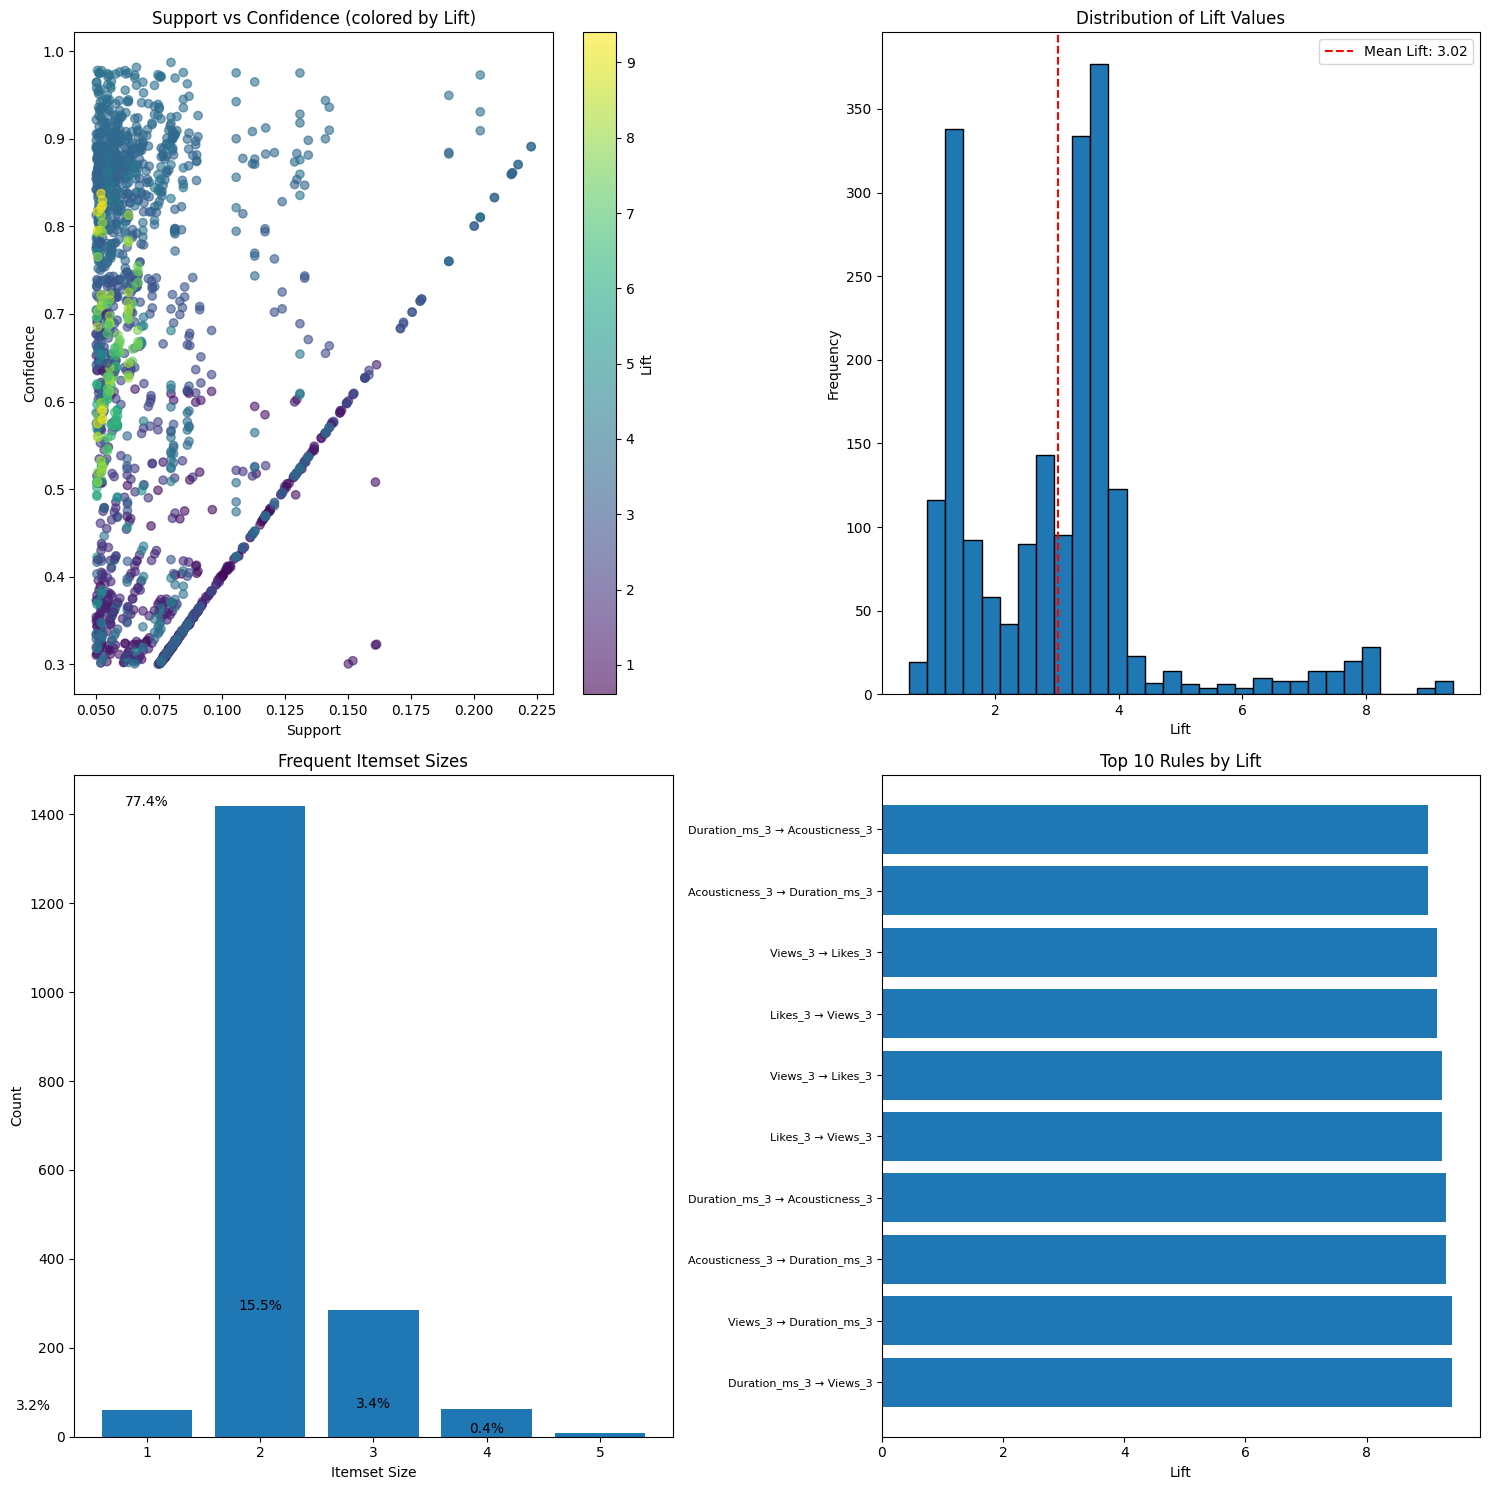

In [17]:
# Run the analysis
results = comprehensive_market_basket_analysis(binary_df)

# Print summary statistics
print("Analysis Summary:")
for key, value in results['summary'].items():
    print(f"{key}: {value:.2f}")

# Show visualizations
plt.show()

In [24]:
def analyze_feature_level_transitions(rules, min_lift=2.0):
    # Group features by their base characteristic
    feature_groups = {
        'energy': ['Energy_0', 'Energy_1', 'Energy_2', 'Energy_3'],
        'danceability': ['Danceability_0', 'Danceability_1', 'Danceability_2', 'Danceability_3'],
        'acousticness': ['Acousticness_0', 'Acousticness_1', 'Acousticness_2', 'Acousticness_3'],
        'valence': ['Valence_0', 'Valence_1', 'Valence_2', 'Valence_3']
    }
    
    cross_feature_rules = rules[
        rules['antecedents'].apply(lambda x: any(f in str(x) for group in feature_groups.values() for f in group)) &
        rules['consequents'].apply(lambda x: any(f in str(x) for group in feature_groups.values() for f in group)) &
        (rules['lift'] >= min_lift)
    ]
    
    return cross_feature_rules.sort_values('lift', ascending=False)

def analyze_high_performance_combinations(rules, min_confidence=0.7):
    high_performance_metrics = ['Views_3', 'Likes_3', 'Comments_3', 'Stream_3']
    
    success_rules = rules[
        rules['consequents'].apply(lambda x: any(metric in str(x) for metric in high_performance_metrics)) &
        (rules['confidence'] >= min_confidence)
    ]
    
    return success_rules.sort_values('confidence', ascending=False)

def analyze_feature_clusters(binary_df):

    feature_levels = ['_0', '_1', '_2', '_3']
    clusters = {}
    
    for level in feature_levels:
        level_features = [col for col in binary_df.columns if col.endswith(level)]
        level_data = binary_df[level_features]
        
        # Find frequent combinations within this level
        frequent_itemsets = apriori(level_data, min_support=0.1, use_colnames=True)
        clusters[f'level{level}'] = analyze_feature_combinations(frequent_itemsets)
    
    return clusters

def analyze_engagement_progression(rules):

    engagement_metrics = ['Views', 'Likes', 'Comments']
    progression_rules = {}
    
    for metric in engagement_metrics:
        # Look for rules where lower levels lead to higher levels
        metric_rules = rules[
            rules['antecedents'].apply(lambda x: f'{metric}_2' in str(x)) &
            rules['consequents'].apply(lambda x: f'{metric}_3' in str(x))
        ]
        progression_rules[metric] = metric_rules.sort_values('confidence', ascending=False)
    
    return progression_rules

def generate_comprehensive_insights(binary_df):

    # Generate base itemsets and rules
    frequent_itemsets = apriori(binary_df, min_support=0.05, use_colnames=True)
    rules = association_rules(frequent_itemsets, num_itemsets=binary_df.shape[0],metric='confidence', min_threshold=0.3)
    
    insights = {
        'feature_transitions': analyze_feature_level_transitions(rules),
        'high_performance': analyze_high_performance_combinations(rules),
        'feature_clusters': analyze_feature_clusters(binary_df),
        'engagement_progression': analyze_engagement_progression(rules),
        'musical_patterns': analyze_musical_characteristics(rules),
        'engagement_patterns': analyze_engagement_patterns(rules),
        'common_combinations': analyze_feature_combinations(frequent_itemsets)
    }
    
    return insights

# Function to create a visualization of the insights
def visualize_insights(insights):
    plt.figure(figsize=(15, 10))
    
    # Get top transitions
    transitions = insights['feature_transitions'].head(10)
    
    # Create pivot table for heatmap
    transition_matrix = transitions.pivot_table(
        values='lift', 
        index='antecedents', 
        columns='consequents'
    )
    
    # Create single heatmap
    sns.heatmap(
        transition_matrix,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0
    )
    plt.title('Feature Level Transitions')
    plt.tight_layout()
    
    return plt

/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/si

Top Feature Level Relationships:
                                      antecedents                                  consequents  antecedent support  consequent support   support  confidence      lift  representativity  leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski
1861                          (Views_3, Energy_0)  (Duration_ms_3, Loudness_0, Acousticness_3)            0.089109            0.062049  0.051972    0.583238  9.399598               1.0  0.046443    2.250565       0.981032  0.523981   0.555667    0.710415
1847  (Duration_ms_3, Loudness_0, Acousticness_3)                          (Views_3, Energy_0)            0.062049            0.089109  0.051972    0.837593  9.399598               1.0  0.046443    5.608682       0.952729  0.523981   0.821705    0.710415
1856                    (Duration_ms_3, Energy_0)        (Acousticness_3, Loudness_0, Views_3)            0.088189            0.063277  0.051972    0.589327  9.313465               1.0  0.046392    2.28

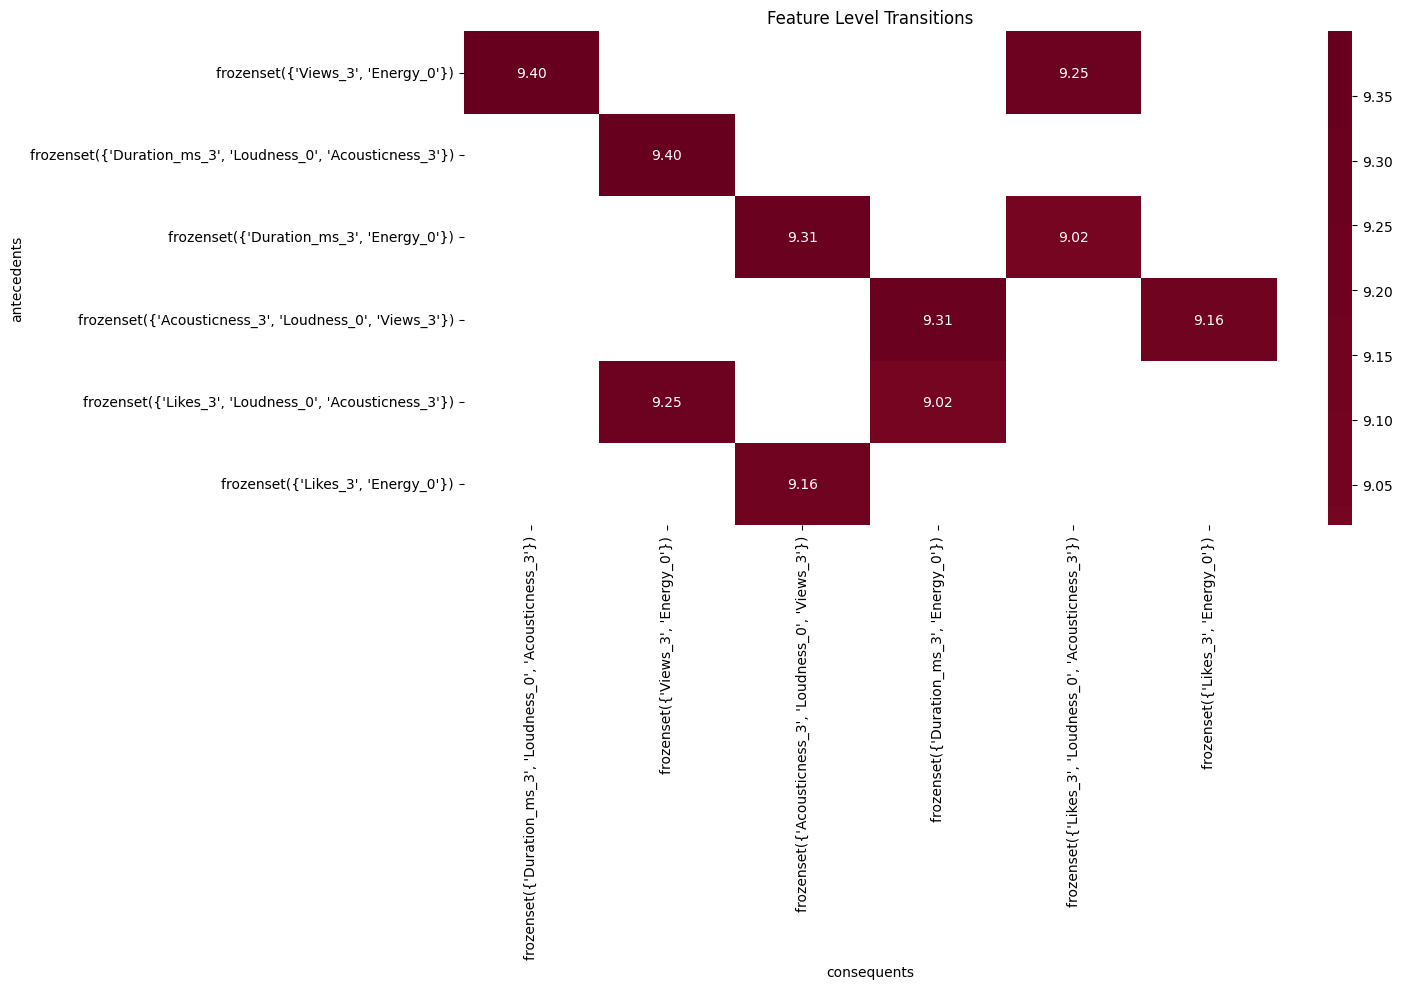

In [25]:
# Generate comprehensive insights
insights = generate_comprehensive_insights(binary_df)

# 1. Feature Level Relationships
print("Top Feature Level Relationships:")
print(insights['feature_transitions'].head().to_string())

# 3. Feature Clusters Analysis
print("\nFeature Level Clusters:")
for level, clusters in insights['feature_clusters'].items():
    print(f"\n{level}:")
    print(clusters.head().to_string())

# 4. Engagement Progression Analysis
print("\nEngagement Progression Patterns:")
for metric, patterns in insights['engagement_progression'].items():
    print(f"\n{metric} Progression:")
    print(patterns.head().to_string())

# Create visualizations
vis = visualize_insights(insights)


In [32]:
print("\nPatterns Leading to High Engagement:")
print(insights['high_performance'].head().to_string())

print(df.iloc[1296])


Patterns Leading to High Engagement:
                                   antecedents consequents  antecedent support  consequent support   support  confidence      lift  representativity  leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski
1296  (Danceability_0, Duration_ms_3, Likes_3)   (Views_3)            0.067267            0.249987  0.066039    0.981749  3.927197               1.0  0.049223   41.094451       0.799120  0.262879   0.975666    0.622960
1577   (Speechiness_1, Duration_ms_3, Likes_3)   (Views_3)            0.060822            0.249987  0.059389    0.976451  3.906003               1.0  0.044185   31.848757       0.792164  0.236216   0.968602    0.607010
1515      (Duration_ms_3, Loudness_0, Likes_3)   (Views_3)            0.086756            0.249987  0.084659    0.975825  3.903502               1.0  0.062971   31.024919       0.814481  0.335836   0.967768    0.657240
1466           (Key_2, Duration_ms_3, Likes_3)   (Views_3)            0.052432        

In [27]:
def find_matching_songs(original_df, binary_df, feature_combination):
    """
    Find songs that match specific feature combinations from the binary encoded data
    """
    # Make sure indices match
    binary_df = binary_df.reset_index(drop=True)
    original_df = original_df.reset_index(drop=True)
    
    # Create mask for each feature level
    masks = []
    for feature, level in feature_combination.items():
        column_name = f"{feature}_{level}"
        if column_name in binary_df.columns:
            masks.append(binary_df[column_name] == 1)
    
    # Combine all masks
    if masks:
        final_mask = masks[0]
        for mask in masks[1:]:
            final_mask = final_mask & mask
        
        # Get matching songs with relevant details
        matching_songs = original_df[final_mask][['Track', 'Artist', 'Album', 'Views', 'Likes', 
                                                'Energy', 'Duration_ms', 'Loudness', 'Acousticness']]
        
        return matching_songs
    return pd.DataFrame()

# Example: Find songs with the strongest pattern
# (Views_3, Energy_0) → (Duration_ms_3, Loudness_0, Acousticness_3)
feature_combination = {
    'Views': 3,
    'Energy': 0,
    'Duration_ms': 3,
    'Loudness': 0,
    'Acousticness': 3
}

matching_songs = find_matching_songs(df, binary_df, feature_combination)

if not matching_songs.empty:
    print(f"\nFound {len(matching_songs)} matching songs:")
    print("\nSample of matching songs:")
    print(matching_songs.head().to_string())
    
    # Get summary statistics of the matching songs
    print("\nSummary statistics of matching songs:")
    print(matching_songs.describe().round(2))
else:
    print("No songs found matching these criteria")


Found 1016 matching songs:

Sample of matching songs:
                                                    Track         Artist                                 Album      Views    Likes  Energy  Duration_ms  Loudness  Acousticness
152                                             Antologia        Shakira                        Pies Descalzos   359765.0   4970.0   0.403     254240.0   -11.059         0.500
205  Here Comes Santa Claus (Right Down Santa Claus Lane)  Elvis Presley                Elvis' Christmas Album   282465.0   4533.0   0.236     115827.0   -16.982         0.968
275                                      Somethin' Stupid  Frank Sinatra                     The World We Knew   420791.0   5476.0   0.338     162493.0   -12.902         0.736
280                          Silent Night - 1999 Remaster  Frank Sinatra  A Jolly Christmas From Frank Sinatra    43026.0    932.0   0.118     146293.0   -17.620         0.945
295                                             Your Song     Elt